# Exploratory Data Analysis

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
df_additional = pd.read_csv('data/Rainfall.csv') 

In [27]:
df_train.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [28]:
train = df_train.copy()
train.drop(['id', 'day'], axis=1, inplace=True)
train.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


- 2190 observations
- we removed columns 'id' and 'day' from the data as they are not useful for the model
- we will use the 'rainfall' column as the target variable

In [29]:
X_train = train.drop('rainfall', axis=1)
Y_train = train['rainfall']
target = 'rainfall'

# Info about datset

In [30]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pressure       2190 non-null   float64
 1   maxtemp        2190 non-null   float64
 2   temparature    2190 non-null   float64
 3   mintemp        2190 non-null   float64
 4   dewpoint       2190 non-null   float64
 5   humidity       2190 non-null   float64
 6   cloud          2190 non-null   float64
 7   sunshine       2190 non-null   float64
 8   winddirection  2190 non-null   float64
 9   windspeed      2190 non-null   float64
 10  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 188.3 KB


- no missing values
- only numerical columns (target is int, others float)

In [31]:
X_train.describe()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703
std,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659
min,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000
25%,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000
50%,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000
75%,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000
max,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000


- pressure - hPa
- temperature, dewpoint - °C
- humidity, cloud - integer-valued percentages
- sunshine - hours of sunshine per day
- winddirection - integer angles
- windspeed - km/h

### Info about target

In [32]:
train['rainfall'].describe()

count    2190.000000
mean        0.753425
std         0.431116
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: rainfall, dtype: float64

In [33]:
train['rainfall'].value_counts()

1    1650
0     540
Name: rainfall, dtype: int64

- target variable is imbalanced - 1s are 3 times more than 0s

## Correlation

<AxesSubplot:>

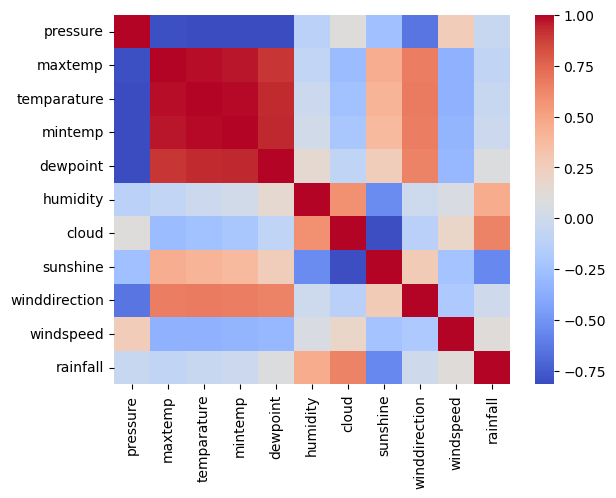

In [34]:
corr = train.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')

- clear negative correlation beetwen 'sunshine' and target variable
- big candidates for removal: 'maxtemp', 'mintemp', 'temperature' , 'dewpoint' (reasonable to leave only one of them - probably 'temperature' or 'dewpoint')

#### Importance of variables - model

In [35]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

importances = model.feature_importances_
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_importance = feature_importance.sort_values(by = 'Importance', ascending=False)
print(feature_importance)

         Feature  Importance
6          cloud    0.469018
7       sunshine    0.082561
9      windspeed    0.074572
4       dewpoint    0.066069
0       pressure    0.060101
5       humidity    0.059160
1        maxtemp    0.057619
3        mintemp    0.051024
8  winddirection    0.040841
2    temparature    0.039035


We got more information about importance of variables, so we can have more information about which variables we can maybe remove.
We decided to remove these columns: 'maxtemp', 'mintemp', 'temperature', 'winddirection'.

In [37]:
X_train2 = X_train.drop(columns=['maxtemp', 'mintemp', 'temparature', 'winddirection'])

In [38]:
X_train2

,pressure,dewpoint,humidity,cloud,sunshine,windspeed
0,1017.4,19.4,87.0,88.0,1.1,17.2
1,1019.5,15.4,95.0,91.0,0.0,21.9
2,1024.1,9.3,75.0,47.0,8.3,18.1
3,1013.4,16.8,95.0,95.0,0.0,35.6
4,1021.8,9.6,52.0,45.0,3.6,24.8
...,...,...,...,...,...,...
2185,1014.6,19.9,97.0,88.0,0.1,22.1
2186,1012.4,15.3,91.0,88.0,0.0,35.3
2187,1013.3,12.6,79.0,79.0,5.0,32.9
2188,1022.3,14.7,92.0,93.0,0.1,18.0


## Outliers

c:\Users\Ola\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
c:\Users\Ola\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
c:\Users\Ola\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
c:\Users\Ola\anaconda3\lib\site-packa

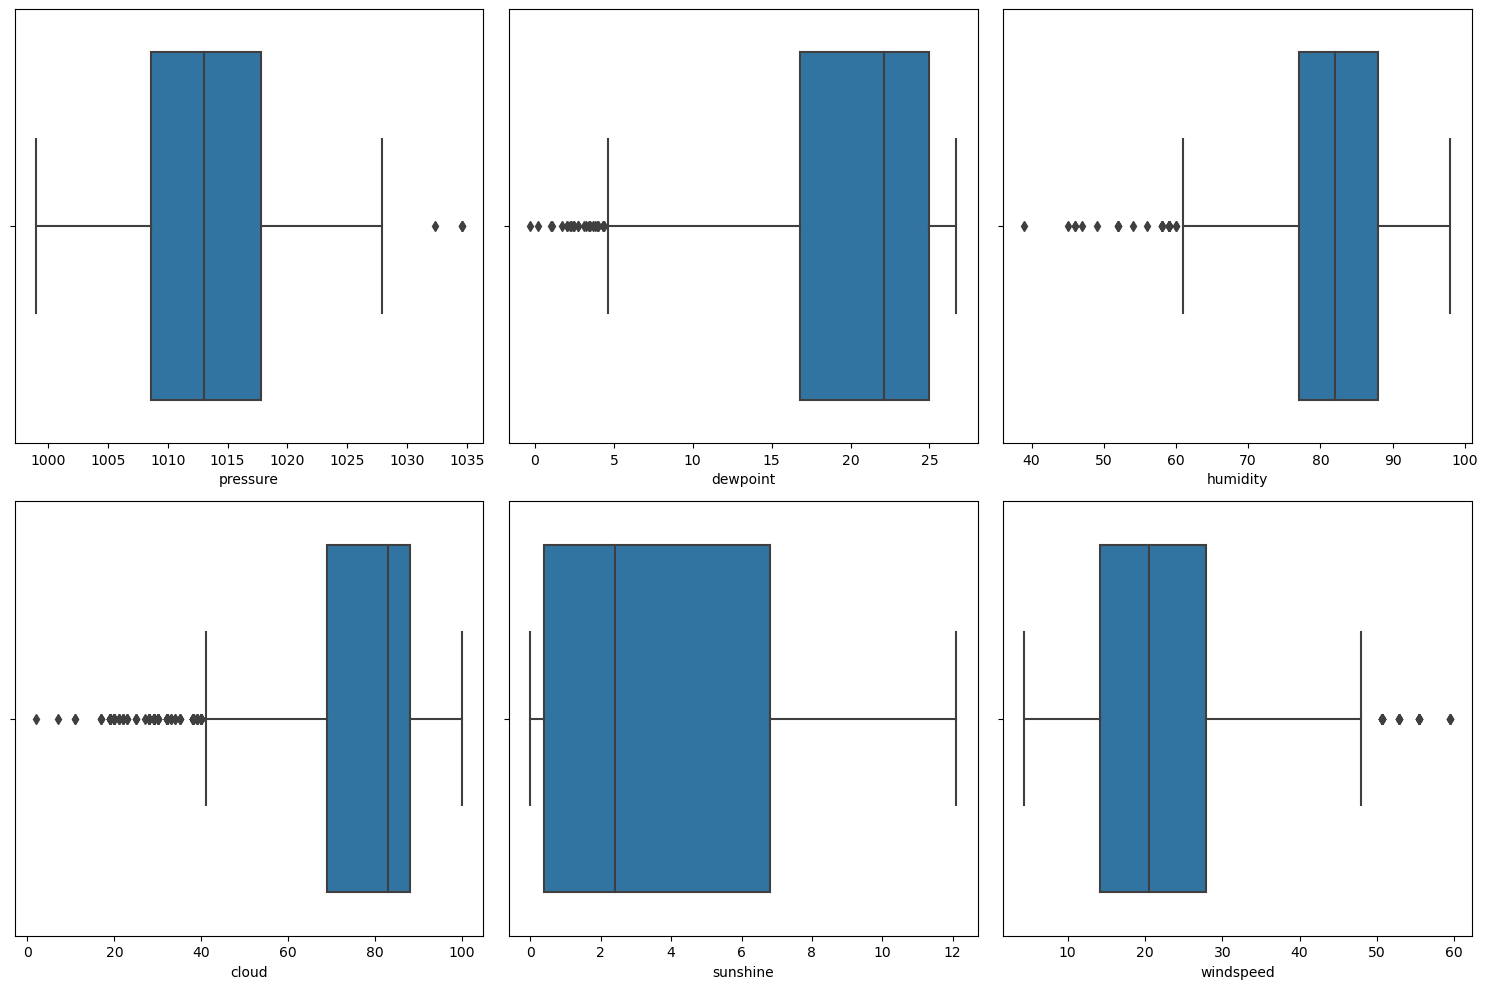

In [59]:
fig, axs = plt.subplots(2, 3, figsize=(15,10))
axs = axs.flatten()
for i in X_train2.columns:
    sns.boxplot(X_train2[i], ax= axs[X_train2.columns.get_loc(i)])
plt.tight_layout()
plt.show()

For removing outliers:
- A milder criterion for 'cloud', 'humidity', and 'dewpoint' can be applied. Instead of 1.5 × IQR, we will try 3.0 × IQR (less aggressive filtering).
- For 'pressure' and 'windspeed', where outliers are more obvious, the standard 1.5 × IQR can be used.
- For sunshine, it seems that the outliers are natural and can remain.

In [75]:
columns_to_check = {
    'pressure': 1.5,  # Standard 1.5×IQR
    'dewpoint': 3.0,  # Less aggressive filtration
    'humidity': 3.0,
    'cloud': 3.0,
    'windspeed': 1.5,
}

X_train2_filtered = X_train2.copy()

for col, iqr_multiplier in columns_to_check.items():
    Q1 = X_train2_filtered[col].quantile(0.25)
    Q3 = X_train2_filtered[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - iqr_multiplier * IQR
    upper_bound = Q3 + iqr_multiplier * IQR
    
    X_train2_filtered = X_train2_filtered[(X_train2_filtered[col] >= lower_bound) & (X_train2_filtered[col] <= upper_bound)]

print(len(X_train2))
print(len(X_train2_filtered))

2190
2153


Let's check exactly how many rows contain outliers (according to boxplots):

In [76]:
columns_to_check = ['pressure', 'dewpoint', 'humidity', 'cloud', 'sunshine', 'windspeed']

outlier_mask = pd.DataFrame(False, index=X_train2.index, columns=columns_to_check)

for col in columns_to_check:
    Q1 = X_train2[col].quantile(0.25) 
    Q3 = X_train2[col].quantile(0.75)  
    IQR = Q3 - Q1 
    lower_bound = Q1 - 1.5 * IQR 
    upper_bound = Q3 + 1.5 * IQR 

    outlier_mask[col] = (X_train2[col] < lower_bound) | (X_train2[col] > upper_bound)

num_rows_with_outliers = outlier_mask.any(axis=1).sum()
num_rows_with_outliers

193

## Distribution of variables

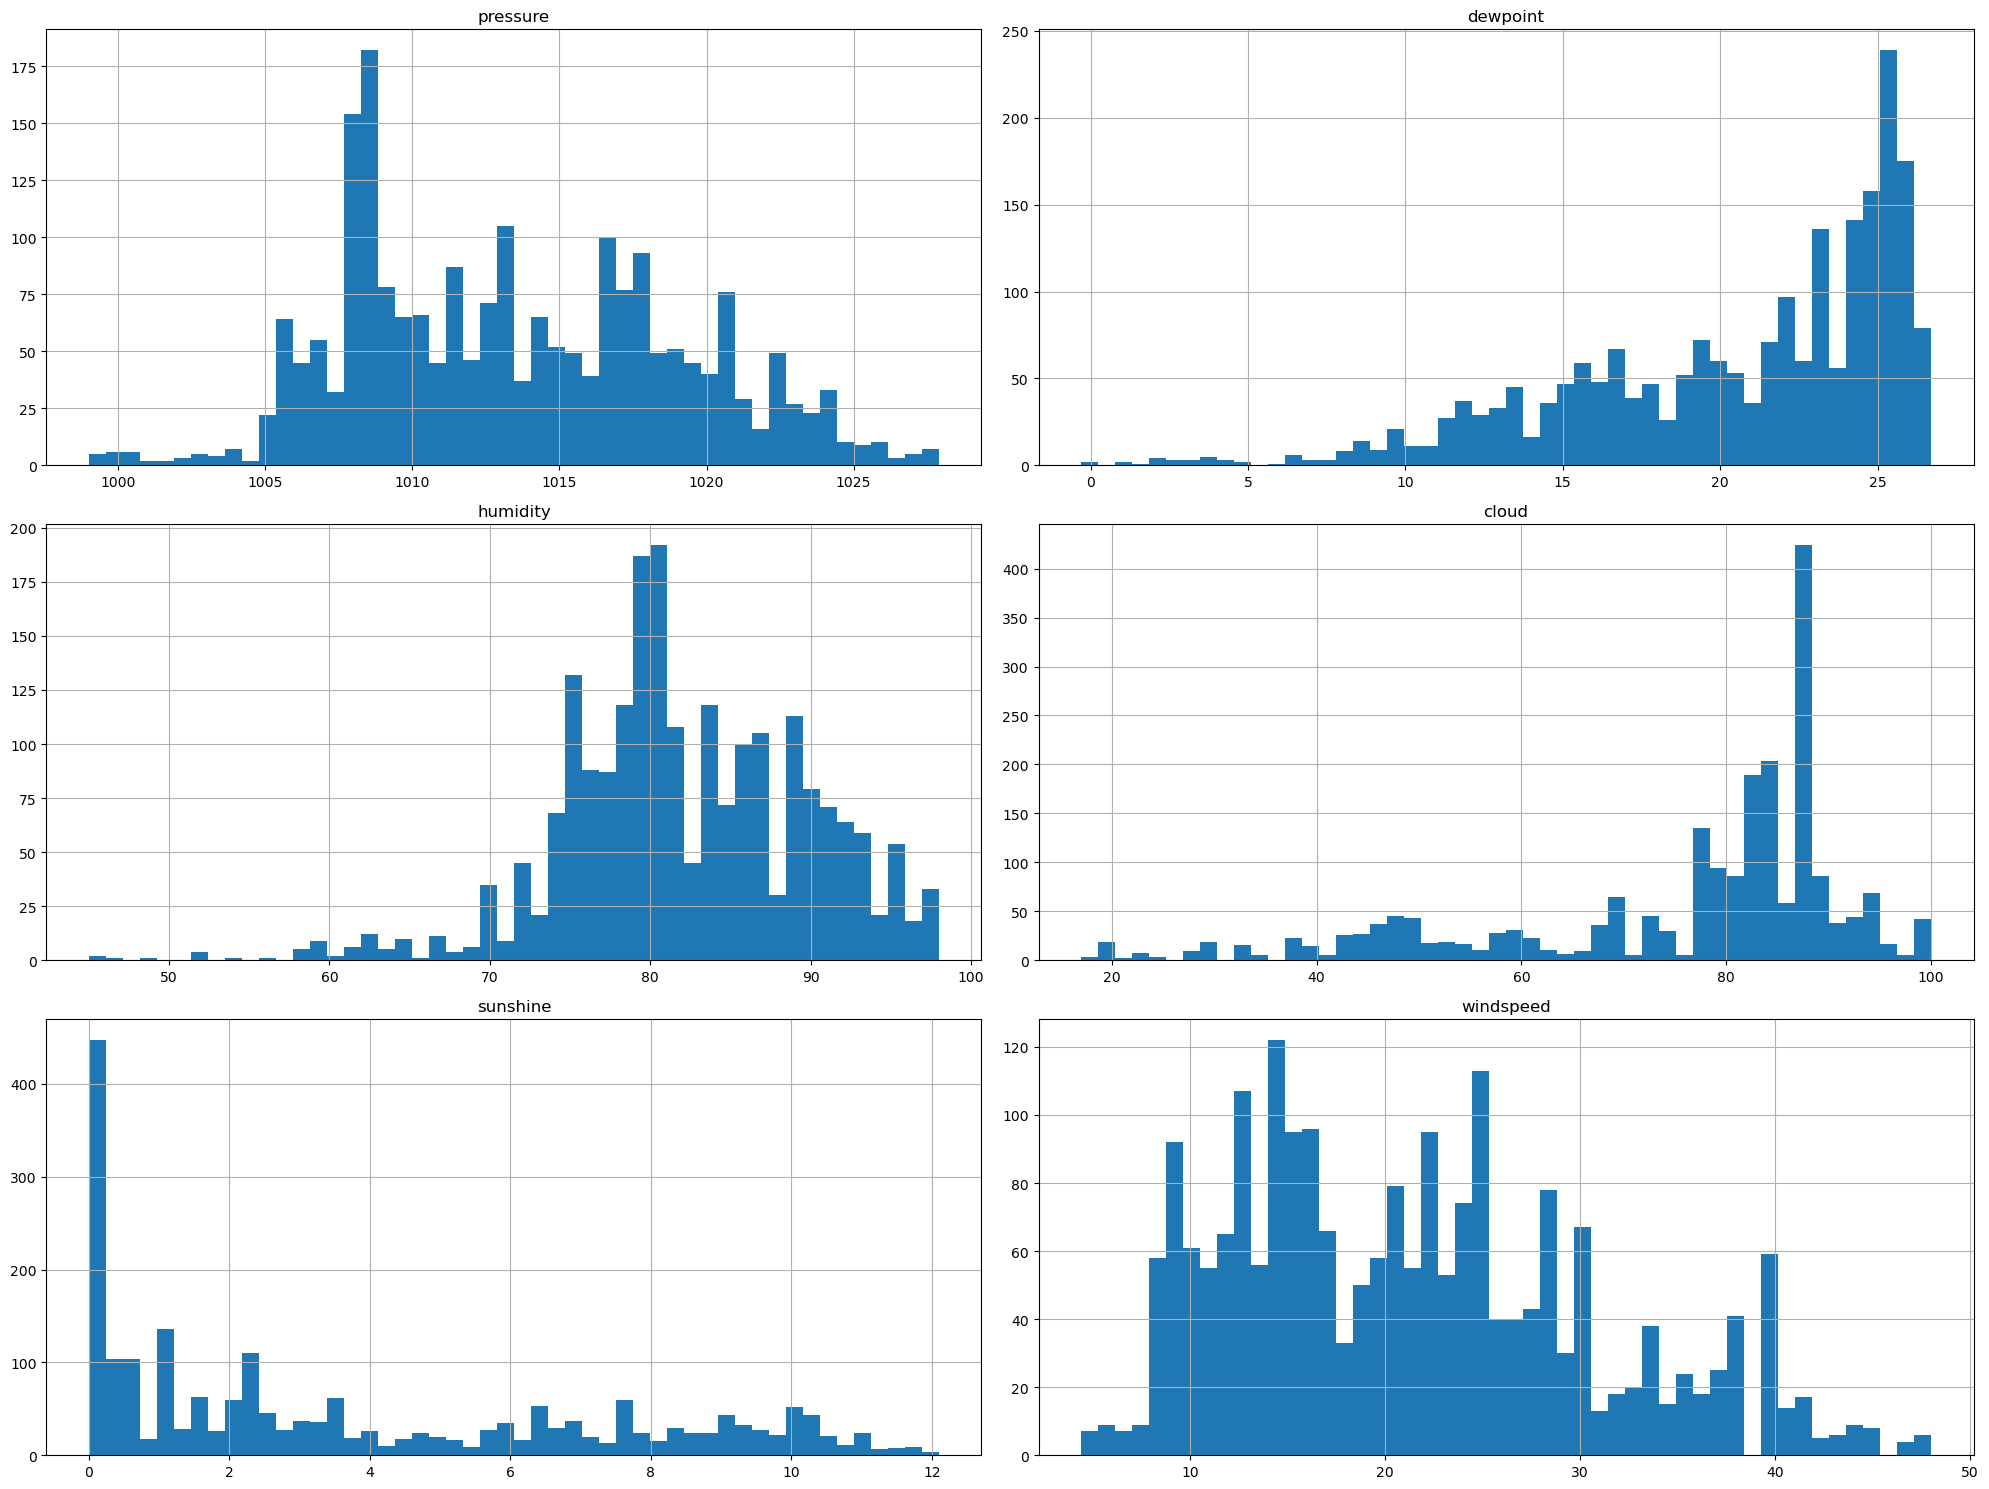

In [77]:
X_train2_filtered.hist(bins=50, figsize=(20,15))
plt.tight_layout()
plt.show()

## Normalization

In [40]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [78]:
X_train2_normalized = X_train2_filtered.copy()

# Standardization for variables with a normal distribution
scaler_standard = StandardScaler()
X_train2_normalized[['pressure', 'windspeed']] = scaler_standard.fit_transform(X_train2_filtered[['pressure', 'windspeed']])

# Log transformation for skewed variables
for col in ['humidity', 'dewpoint', 'cloud', 'sunshine']:
    X_train2_normalized[col] = np.log1p(X_train2_filtered[col])  # log1p(X) = log(X + 1)

# Min-Max Scaling for humidity and sunshine because log transformation is not ideal
scaler_minmax = MinMaxScaler()
X_train2_normalized[['humidity', 'cloud', 'sunshine']] = scaler_minmax.fit_transform(X_train2_normalized[['humidity', 'cloud', 'sunshine']])

X_train2_normalized.head()

,pressure,dewpoint,humidity,cloud,sunshine,windspeed
0,0.698777,3.015535,0.846332,0.926665,0.288398,-0.452229
1,1.075396,2.797281,0.959853,0.945887,0.000000,0.054835
2,1.900370,2.332144,0.655063,0.568679,0.866829,-0.355132
3,-0.018592,2.879198,0.959853,0.970562,0.000000,1.532874
4,1.487883,2.360854,0.184807,0.544004,0.593193,0.367704


In [79]:
X_train2_normalized.describe()

,pressure,dewpoint,humidity,cloud,sunshine,windspeed
count,2.153000e+03,2153.000000,2153.000000,2153.000000,2153.000000,2.153000e+03
mean,4.886343e-14,3.027566,0.765411,0.819904,0.473868,-1.650122e-16
std,1.000232e+00,0.329499,0.125678,0.174408,0.336115,1.000232e+00
min,-2.601121e+00,-0.356675,0.000000,0.000000,0.000000,-1.833171e+00
25%,-8.794352e-01,2.879198,0.688953,0.787433,0.130790,-7.866761e-01
50%,-9.032920e-02,3.148453,0.770014,0.893142,0.475694,-9.620548e-02
75%,7.525795e-01,3.258097,0.861074,0.926665,0.798458,6.374196e-01
max,2.581871e+00,3.321432,1.000000,1.000000,1.000000,2.870661e+00


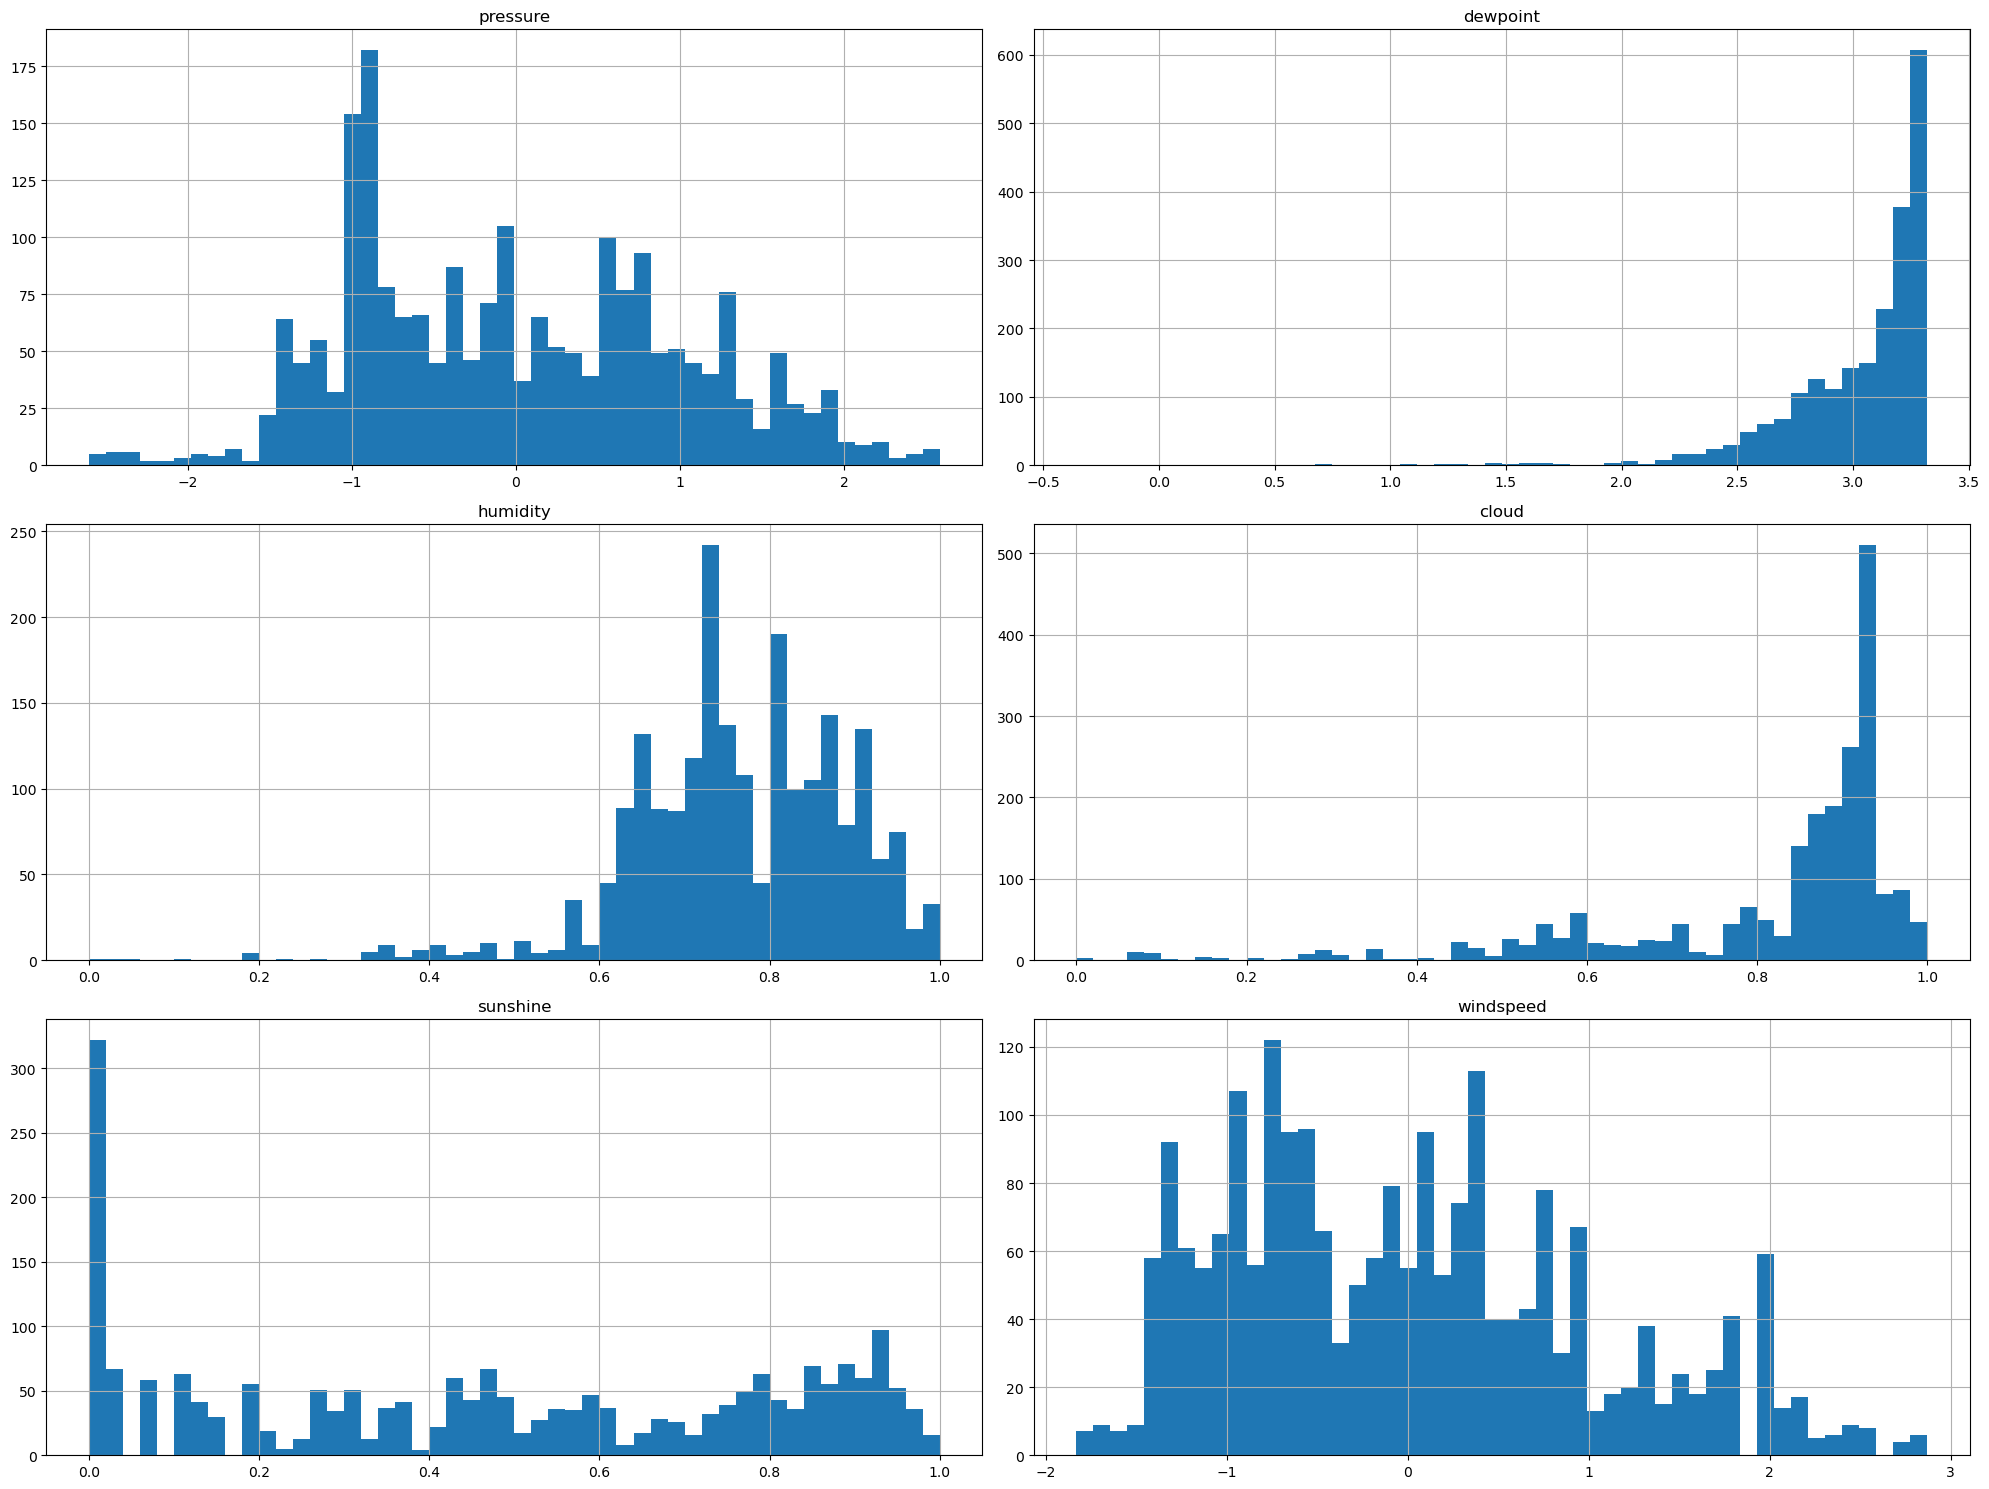

In [80]:
X_train2_normalized.hist(bins=50, figsize=(20,15))
plt.tight_layout()
plt.show()